In [21]:
import os, sys
from pathlib import Path
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

# make tidy/src importable
sys.path.append(os.path.abspath("../src"))

# outputs
OUT_PROB = Path("../outputs/unet_prob")
OUT_BIN  = Path("../outputs/unet_bin")
OUT_VIS  = Path("../outputs/vis")
OUT_PROB.mkdir(parents=True, exist_ok=True)
OUT_BIN.mkdir(parents=True, exist_ok=True)
OUT_VIS.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_H, IMG_W = 360, 640

# IMPORTANT: point to your checkpoint
CKPT_PATH = Path("../../models/checkpoints/unet_tusimple_best.pt")  # adjust if needed


In [22]:
from models import UNetSmall


In [23]:
def load_unet(ckpt_path: Path):
    model = UNetSmall().to(DEVICE)
    ckpt = torch.load(str(ckpt_path), map_location=DEVICE)

    # your checkpoint uses ckpt["model"]
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model

model = load_unet(CKPT_PATH)
print("Loaded model from:", CKPT_PATH)


Loaded model from: ..\..\models\checkpoints\unet_tusimple_best.pt


C:\Users\ankit\AppData\Local\Temp\ipykernel_28092\748020332.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(ckpt_path), map_location=DEVICE)


In [24]:
def preprocess_frame_bgr(frame_bgr):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (IMG_W, IMG_H), interpolation=cv2.INTER_LINEAR)
    x = (rgb.astype(np.float32) / 255.0)
    x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0)
    return x, rgb


In [25]:
def unet_predict_masks(frame_bgr, thr=0.30):
    x, rgb_resized = preprocess_frame_bgr(frame_bgr)
    with torch.no_grad():
        logits = model(x.to(DEVICE))
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()  # HxW, 0..1

    bin_mask = (prob >= thr).astype(np.uint8) * 255
    return rgb_resized, prob, bin_mask


In [26]:
# Put one test image path here
img_path = Path(r"E:\dl_cv_mini_project\road_lane_detection\data\raw\tusimple\test_set\clips\0530\1492626047222176976_0\13.jpg")  # change to a real jpg file path
# Example: img_path = Path(r"../../data/raw/tusimple/test_set/clips/0313-1/6040/20.jpg")

frame = cv2.imread(str(img_path))
assert frame is not None, f"Cannot read image: {img_path}"

thr = 0.30
rgb_resized, prob, bin_mask = unet_predict_masks(frame, thr=thr)

# --------- UNIQUE SAFE NAME (IMPORTANT FIX) ----------
parts = img_path.parts[-3:]   # e.g. ["0530", "1492626047222176976_0", "13.jpg"]
safe_name = "__".join(parts).replace(".jpg", "")

prob_img = (prob * 255).clip(0, 255).astype(np.uint8)

# save probability mask
cv2.imwrite(
    str(OUT_PROB / f"{safe_name}_prob.png"),
    prob_img
)

# save binary mask
cv2.imwrite(
    str(OUT_BIN / f"{safe_name}_bin.png"),
    bin_mask
)

# 🔴 VERY IMPORTANT: save the resized original image too
cv2.imwrite(
    str(OUT_VIS / f"{safe_name}_orig.png"),
    cv2.cvtColor(rgb_resized, cv2.COLOR_RGB2BGR)
)

print("Saved:")
print(OUT_PROB / f"{safe_name}_prob.png")
print(OUT_BIN  / f"{safe_name}_bin.png")
print(OUT_VIS  / f"{safe_name}_orig.png")



Saved:
..\outputs\unet_prob\0530__1492626047222176976_0__13_prob.png
..\outputs\unet_bin\0530__1492626047222176976_0__13_bin.png
..\outputs\vis\0530__1492626047222176976_0__13_orig.png


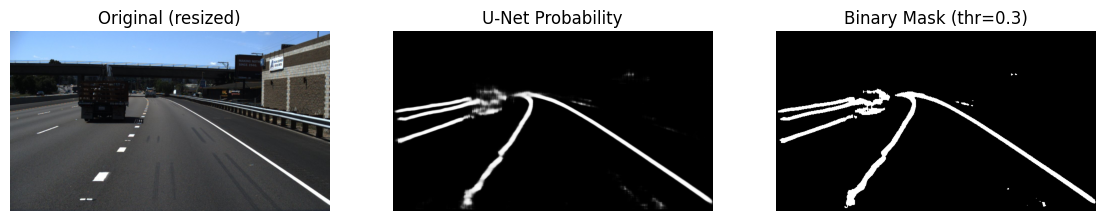

In [27]:
plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.title("Original (resized)"); plt.imshow(rgb_resized); plt.axis("off")
plt.subplot(1,3,2); plt.title("U-Net Probability"); plt.imshow(prob, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title(f"Binary Mask (thr={thr})"); plt.imshow(bin_mask, cmap="gray"); plt.axis("off")
plt.show()


## overall Results 

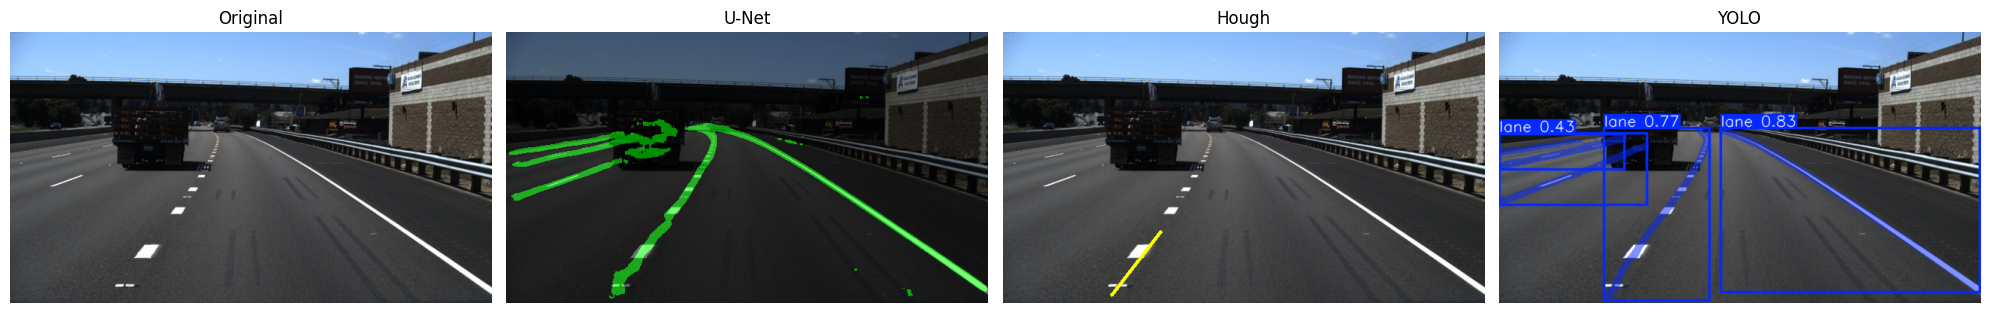

Repo root: E:\dl_cv_mini_project\road_lane_detection
YOLO weights: E:\dl_cv_mini_project\road_lane_detection\runs\segment\train2\weights\best.pt
Done.


In [16]:
# ===================== FINAL RESULTS CELL (Robust + Minimal) =====================
# Original | U-Net overlay | Hough overlay | YOLO overlay
# Fixes YOLO path by auto-finding repo root (where "runs/" exists).

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ---- outputs base (keep as is if it worked before) ----
OUT_BASE = Path("../outputs") if Path("../outputs").exists() else Path("tidy/outputs")
VIS_DIR   = OUT_BASE / "vis"
BIN_DIR   = OUT_BASE / "unet_bin"
HOUGH_DIR = OUT_BASE / "hough_overlay"

# ---- auto-find repo root so runs/... works regardless of notebook location ----
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(10):
        if (p / "runs").exists():   # this is the key folder we know exists in your repo root
            return p
        p = p.parent
    raise FileNotFoundError("Could not locate repo root (folder containing 'runs').")

REPO = find_repo_root(Path.cwd())
YOLO_W = REPO / "runs/segment/train2/weights/best.pt"   # uses your confirmed location
yolo = YOLO(str(YOLO_W))

# ---- how many images ----
N = 10

def bgr2rgb(im): 
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

def overlay_mask(rgb, mask_u8, alpha=0.55):
    col = np.zeros_like(rgb)
    col[..., 1] = mask_u8
    return (rgb*(1-alpha) + col*alpha).astype(np.uint8)

orig_list = sorted(VIS_DIR.glob("*_orig.png"))[:N]
if not orig_list:
    raise RuntimeError(f"No *_orig.png found in {VIS_DIR}. Run your U-Net mask generation first.")

rows, cols = len(orig_list), 4
plt.figure(figsize=(cols*5, rows*3.2))

for i, orig_p in enumerate(orig_list, start=1):
    stem = orig_p.name.replace("_orig.png", "")
    orig_bgr = cv2.imread(str(orig_p))
    orig_rgb = bgr2rgb(orig_bgr)

    # U-Net overlay (reads existing bin mask)
    bin_p = BIN_DIR / f"{stem}_bin.png"
    if bin_p.exists():
        m = cv2.imread(str(bin_p), cv2.IMREAD_GRAYSCALE)
        m = cv2.resize(m, (orig_rgb.shape[1], orig_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
        unet_vis = overlay_mask(orig_rgb, m)
    else:
        unet_vis = orig_rgb

    # Hough overlay (reads existing)
    hough_p = HOUGH_DIR / f"{stem}_hough.png"
    hough_rgb = bgr2rgb(cv2.imread(str(hough_p))) if hough_p.exists() else None

    # YOLO overlay (runs now)
    r = yolo.predict(source=str(orig_p), imgsz=960, conf=0.2, iou=0.5, verbose=False, save=False)[0]
    yolo_bgr = r.plot()
    yolo_rgb = bgr2rgb(yolo_bgr) if yolo_bgr is not None else orig_rgb

    ax1 = plt.subplot(rows, cols, (i-1)*cols + 1); ax1.imshow(orig_rgb);  ax1.set_title("Original");      ax1.axis("off")
    ax2 = plt.subplot(rows, cols, (i-1)*cols + 2); ax2.imshow(unet_vis);  ax2.set_title("U-Net");         ax2.axis("off")
    ax3 = plt.subplot(rows, cols, (i-1)*cols + 3)
    if hough_rgb is not None:
        ax3.imshow(hough_rgb); ax3.set_title("Hough"); ax3.axis("off")
    else:
        ax3.text(0.5,0.5,"No Hough",ha="center",va="center"); ax3.axis("off")
    ax4 = plt.subplot(rows, cols, (i-1)*cols + 4); ax4.imshow(yolo_rgb);  ax4.set_title("YOLO");          ax4.axis("off")

plt.tight_layout()
plt.show()

print("Repo root:", REPO)
print("YOLO weights:", YOLO_W)
print("Done.")


In [19]:
# ===================== ONE-CELL: TRAINING SUMMARY (U-Net + YOLO) =====================
# Prints: epochs trained, approximate training time, and key metrics to paste into PPT.
# Works by reading what is already saved on disk (no re-training).

from pathlib import Path
import re
import pandas as pd
import yaml
import os
from datetime import timedelta

ROOT = Path.cwd()

def find_repo_root(p: Path) -> Path:
    p = p.resolve()
    for _ in range(12):
        if (p / "runs").exists() or (p / "models").exists() or (p / "tidy").exists():
            return p
        p = p.parent
    return Path.cwd().resolve()

REPO = find_repo_root(ROOT)

def fmt_secs(s):
    if s is None:
        return "N/A"
    try:
        return str(timedelta(seconds=int(s)))
    except Exception:
        return "N/A"

def mtime(p: Path):
    return p.stat().st_mtime if p.exists() else None

# --------------------- YOLO (Ultralytics) ---------------------
def yolo_summary(repo: Path):
    runs_seg = repo / "runs" / "segment"
    if not runs_seg.exists():
        return {"found": False, "note": "No runs/segment folder found."}

    # pick the most recent train* folder
    candidates = [d for d in runs_seg.glob("train*") if d.is_dir()]
    if not candidates:
        return {"found": False, "note": "No train* folders in runs/segment."}
    candidates.sort(key=lambda d: d.stat().st_mtime, reverse=True)
    run = candidates[0]

    results_csv = run / "results.csv"
    args_yaml = run / "args.yaml"
    weights_best = run / "weights" / "best.pt"
    weights_last = run / "weights" / "last.pt"

    if not results_csv.exists():
        return {"found": False, "note": f"results.csv not found in {run}."}

    df = pd.read_csv(results_csv)
    epochs = len(df)

    # training time (best-effort):
    # 1) if Ultralytics wrote a 'time' column (rare) use last value
    # 2) else approximate from run folder mtime span of results.csv and weights
    seconds = None
    time_cols = [c for c in df.columns if c.strip().lower() == "time"]
    if time_cols:
        try:
            seconds = float(df[time_cols[0]].iloc[-1])
        except Exception:
            seconds = None
    if seconds is None:
        t0 = min([x for x in [mtime(results_csv), mtime(weights_last), mtime(weights_best)] if x is not None], default=None)
        t1 = max([x for x in [mtime(results_csv), mtime(weights_last), mtime(weights_best)] if x is not None], default=None)
        if t0 is not None and t1 is not None and t1 >= t0:
            seconds = t1 - t0

    # choose "best" row by highest mAP50-95 (mask if present else box)
    metric_candidates = [
        "metrics/mAP50-95(M)", "metrics/mAP50-95(B)",
        "metrics/mAP50(M)",    "metrics/mAP50(B)",
        "metrics/precision(M)","metrics/precision(B)",
        "metrics/recall(M)",   "metrics/recall(B)",
    ]
    best_key = next((k for k in ["metrics/mAP50-95(M)", "metrics/mAP50-95(B)"] if k in df.columns), None)
    if best_key is not None:
        best_idx = df[best_key].astype(float).idxmax()
    else:
        best_idx = df.index[-1]

    best = df.loc[best_idx].to_dict()

    # pull common metrics if present
    def pick(keys):
        for k in keys:
            if k in best:
                return float(best[k])
        return None

    out = {
        "found": True,
        "run_dir": str(run),
        "weights_used": str(weights_best if weights_best.exists() else weights_last),
        "epochs": epochs,
        "train_time": fmt_secs(seconds),
        "best_epoch": int(best.get("epoch", best_idx)),
        "precision": pick(["metrics/precision(M)", "metrics/precision(B)"]),
        "recall":    pick(["metrics/recall(M)", "metrics/recall(B)"]),
        "mAP50":     pick(["metrics/mAP50(M)", "metrics/mAP50(B)"]),
        "mAP50_95":  pick(["metrics/mAP50-95(M)", "metrics/mAP50-95(B)"]),
    }
    return out

# --------------------- U-Net (checkpoints + any saved metrics/history) ---------------------
def unet_summary(repo: Path):
    ckpt_dir = repo / "models" / "checkpoints"
    if not ckpt_dir.exists():
        return {"found": False, "note": "models/checkpoints not found."}

    # infer epochs from filenames like unet_*_epoch10.pt
    epoch_files = list(ckpt_dir.glob("*epoch*.pt"))
    epoch_nums = []
    for p in epoch_files:
        m = re.search(r"epoch(\d+)", p.name)
        if m:
            epoch_nums.append(int(m.group(1)))

    epochs = max(epoch_nums) if epoch_nums else None

    # approx training time from first/last epoch checkpoint mtimes (best-effort)
    if epoch_files and epoch_nums:
        # map epoch->file, pick earliest and latest epoch mtimes
        ep_to_file = {}
        for p in epoch_files:
            m = re.search(r"epoch(\d+)", p.name)
            if m:
                ep_to_file[int(m.group(1))] = p
        if ep_to_file:
            first_ep = min(ep_to_file)
            last_ep  = max(ep_to_file)
            t0 = mtime(ep_to_file[first_ep])
            t1 = mtime(ep_to_file[last_ep])
            train_time = fmt_secs(t1 - t0) if (t0 is not None and t1 is not None and t1 >= t0) else "N/A"
        else:
            train_time = "N/A"
    else:
        train_time = "N/A"

    # try to find saved metrics files (common names)
    metric_files = []
    for pat in ["**/*unet*metric*.csv", "**/*unet*metric*.json", "**/*history*.csv", "**/*history*.json"]:
        metric_files.extend(list(repo.glob(pat)))
    metric_files = [p for p in metric_files if p.is_file()]
    metric_files.sort(key=lambda p: p.stat().st_mtime, reverse=True)

    metrics = {}
    # if there is a csv history/metrics file, try extracting last row fields
    if metric_files:
        p = metric_files[0]
        try:
            if p.suffix.lower() == ".csv":
                df = pd.read_csv(p)
                last = df.iloc[-1].to_dict()
                # pick typical segmentation metrics if present
                for key in ["iou", "IoU", "dice", "Dice", "f1", "F1", "precision", "recall", "accuracy", "acc", "val_iou", "val_dice"]:
                    if key in last:
                        metrics[key] = float(last[key])
            # json optional (keep minimal: skip deep parsing if structure unknown)
        except Exception:
            pass

    best_ckpt = next(iter(ckpt_dir.glob("*best*.pt")), None)
    out = {
        "found": True,
        "ckpt_dir": str(ckpt_dir),
        "best_ckpt": str(best_ckpt) if best_ckpt else "N/A",
        "epochs": epochs if epochs is not None else "N/A",
        "train_time": train_time,
        "metrics_note": (f"Loaded from {metric_files[0]}" if metrics else "No saved U-Net metrics/history file found (only checkpoints)."),
        "metrics": metrics
    }
    return out

# --------------------- PRINT SUMMARY (PPT-ready) ---------------------
y = yolo_summary(REPO)
u = unet_summary(REPO)

print("\n===================== YOLO (Ultralytics) =====================")
if not y.get("found"):
    print("YOLO: NOT FOUND:", y.get("note"))
else:
    print("Run folder      :", y["run_dir"])
    print("Weights used    :", y["weights_used"])
    print("Epochs trained  :", y["epochs"])
    print("Train time (≈)  :", y["train_time"])
    print("Best epoch      :", y["best_epoch"])
    print("Precision       :", y["precision"])
    print("Recall          :", y["recall"])
    print("mAP@0.5         :", y["mAP50"])
    print("mAP@0.5:0.95    :", y["mAP50_95"])

print("\n===================== U-Net =====================")
if not u.get("found"):
    print("U-Net: NOT FOUND:", u.get("note"))
else:
    print("Checkpoint dir  :", u["ckpt_dir"])
    print("Best checkpoint :", u["best_ckpt"])
    print("Epochs trained  :", u["epochs"])
    print("Train time (≈)  :", u["train_time"])
    print("Metrics source  :", u["metrics_note"])
    if u["metrics"]:
        print("Key metrics     :", u["metrics"])
    else:
        print("Key metrics     : N/A (no saved metrics file detected)")



===================== YOLO (Ultralytics) =====================
Run folder      : E:\dl_cv_mini_project\road_lane_detection\runs\segment\train2
Weights used    : E:\dl_cv_mini_project\road_lane_detection\runs\segment\train2\weights\best.pt
Epochs trained  : 50
Train time (≈)  : 4:31:15
Best epoch      : 50
Precision       : 0.5554
Recall          : 0.61956
mAP@0.5         : 0.54073
mAP@0.5:0.95    : 0.19958

===================== U-Net =====================
Checkpoint dir  : E:\dl_cv_mini_project\road_lane_detection\models\checkpoints
Best checkpoint : E:\dl_cv_mini_project\road_lane_detection\models\checkpoints\unet_tusimple_best.pt
Epochs trained  : 10
Train time (≈)  : 0:23:18
Metrics source  : No saved U-Net metrics/history file found (only checkpoints).
Key metrics     : N/A (no saved metrics file detected)


## to test with the custom images

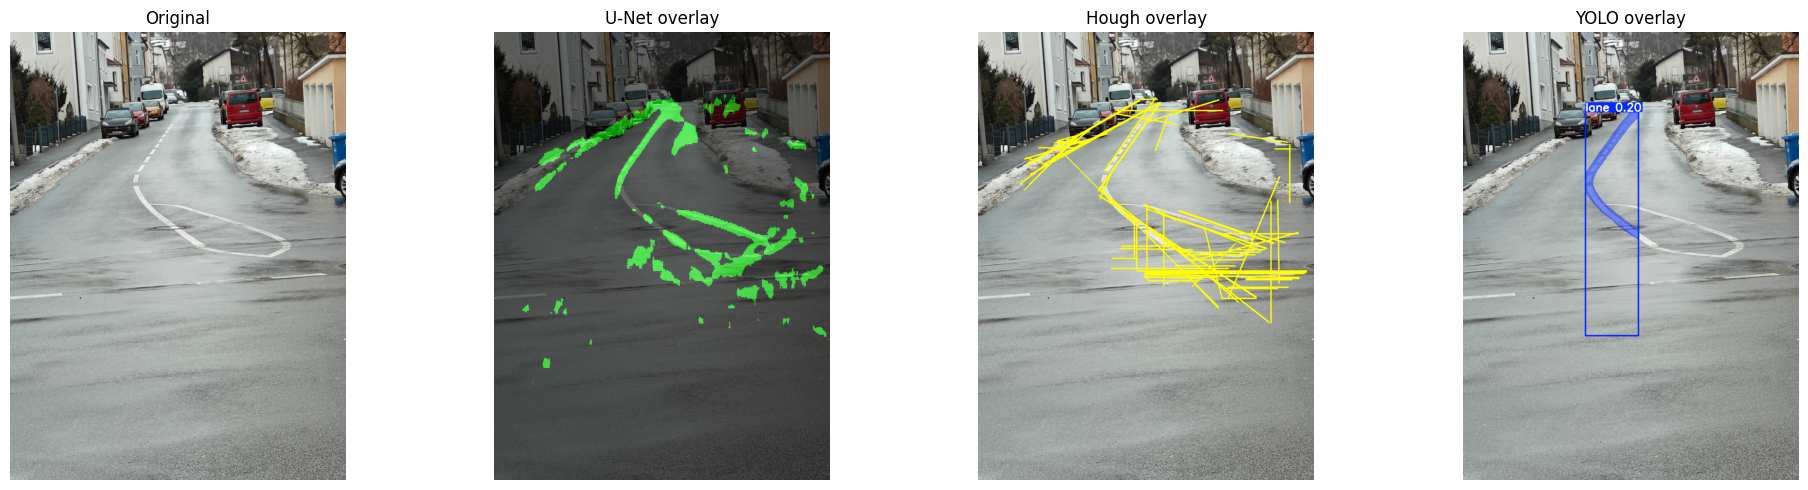

Loaded YOLO: E:\dl_cv_mini_project\road_lane_detection\runs\segment\train2\weights\best.pt
Demo image: E:\dl_cv_mini_project\road_lane_detection\test_img\WhatsApp Image 2026-01-14 at 13.07.05.jpeg


In [31]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ====== CHANGE THIS TO ANY IMAGE ON YOUR PC ======
INPUT_IMAGE = r"E:\dl_cv_mini_project\road_lane_detection\test_img\WhatsApp Image 2026-01-14 at 13.07.05.jpeg"

# ----- locate repo root (so YOLO weights always load) -----
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(10):
        if (p / "runs").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Could not locate repo root (folder containing 'runs').")

REPO = find_repo_root(Path.cwd())
YOLO_W = REPO / "runs/segment/train2/weights/best.pt"
yolo = YOLO(str(YOLO_W))

def bgr2rgb(im): 
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

def overlay_mask(rgb, mask_u8, alpha=0.55):
    col = np.zeros_like(rgb)
    col[..., 1] = mask_u8
    return (rgb*(1-alpha) + col*alpha).astype(np.uint8)

# ----- read your chosen image -----
orig_bgr = cv2.imread(INPUT_IMAGE)
if orig_bgr is None:
    raise FileNotFoundError(f"Cannot read image: {INPUT_IMAGE}")

# ----- U-Net inference (uses your existing model + preprocess if already defined) -----
# This assumes you already ran the earlier U-Net cells and have `model`, `DEVICE`, and `preprocess_frame_bgr`.
if "model" not in globals():
    raise RuntimeError("U-Net model not found. Run your U-Net setup/training/loading cells first.")

x, rgb_small = preprocess_frame_bgr(orig_bgr)  # your function from notebook
import torch
x = x.to(DEVICE)

with torch.no_grad():
    pred = model(x).squeeze().float()
    prob = torch.sigmoid(pred) if (pred.max() > 1.5 or pred.min() < -0.5) else pred
    prob = prob.cpu().numpy()

bin_u8 = ((prob >= 0.5) * 255).astype(np.uint8)
bin_u8 = cv2.resize(bin_u8, (orig_bgr.shape[1], orig_bgr.shape[0]), interpolation=cv2.INTER_NEAREST)

orig_rgb = bgr2rgb(orig_bgr)
unet_vis = overlay_mask(orig_rgb, bin_u8)

# ----- Hough (simple, from your mask) -----
edges = cv2.Canny(bin_u8, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=40, minLineLength=40, maxLineGap=120)
hough_bgr = orig_bgr.copy()
if lines is not None:
    for x1,y1,x2,y2 in lines[:,0,:]:
        cv2.line(hough_bgr, (x1,y1), (x2,y2), (0,255,255), 3)
hough_rgb = bgr2rgb(hough_bgr)

# ----- YOLO inference on the same image -----
r = yolo.predict(source=INPUT_IMAGE, imgsz=960, conf=0.2, iou=0.5, verbose=False, save=False)[0]
yolo_bgr = r.plot()
yolo_rgb = bgr2rgb(yolo_bgr) if yolo_bgr is not None else orig_rgb

# ----- Display -----
plt.figure(figsize=(20, 5))
ax1 = plt.subplot(1,4,1); ax1.imshow(orig_rgb);  ax1.set_title("Original"); ax1.axis("off")
ax2 = plt.subplot(1,4,2); ax2.imshow(unet_vis);  ax2.set_title("U-Net overlay"); ax2.axis("off")
ax3 = plt.subplot(1,4,3); ax3.imshow(hough_rgb); ax3.set_title("Hough overlay"); ax3.axis("off")
ax4 = plt.subplot(1,4,4); ax4.imshow(yolo_rgb);  ax4.set_title("YOLO overlay"); ax4.axis("off")
plt.tight_layout()
plt.show()

print("Loaded YOLO:", YOLO_W)
print("Demo image:", INPUT_IMAGE)
